In [1]:
import pandas as pd
import numpy as np
import re
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from gensim.models import KeyedVectors, Word2Vec
from pathlib import Path
from datetime import datetime
from collections import Counter
import json
from sklearn.model_selection import GridSearchCV
from deep_translator import GoogleTranslator

In [2]:
comparsion_dataset = pd.read_csv('./data/news.csv')

# Приведем датасет к необходимому виду

In [3]:
comparsion_dataset.drop(columns=['source', 'publication_date', 'rubric', 'subrubric', 'tags'], inplace=True)

In [4]:
try:
    russian_stopwords = stopwords.words('russian')
    english_stopwords = stopwords.words('english')
except:
    nltk.download('stopwords')
    russian_stopwords = stopwords.words('russian')
    english_stopwords = stopwords.words('english')

In [5]:
def combine_features(row):
    headline = row['headline_clean']
    body_words = row['body_clean'].split()
    body = ' '.join(body_words)
    return f"{headline} {body}"

def preprocess_text(text):
    if not isinstance(text, str) or len(text) == 0:
        return ""
    
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^а-яё\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    words = [word for word in words if word not in russian_stopwords and len(word) > 2]
    
    return ' '.join(words)

def preprocess_text_en(text):
    if not isinstance(text, str) or len(text) == 0:
        return ""
    
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    words = [word for word in words if word not in english_stopwords and len(word) > 2]
    
    return ' '.join(words)

In [6]:
comparsion_dataset = comparsion_dataset.rename(columns={'title': 'Headline', 'text': 'articleBody'})
comparsion_dataset_eng = comparsion_dataset.copy()

comparsion_dataset['headline_clean'] = comparsion_dataset['Headline'].apply(preprocess_text)
comparsion_dataset['body_clean'] = comparsion_dataset['articleBody'].apply(preprocess_text)

comparsion_dataset['combined_text'] = comparsion_dataset.apply(combine_features, axis=1)

comparsion_dataset = comparsion_dataset[comparsion_dataset['combined_text'].str.len() > 10].reset_index(drop=True)



# comparsion_dataset_eng['headline_clean'] = comparsion_dataset_eng['Headline'].apply(preprocess_text_en)
# comparsion_dataset_eng['body_clean'] = comparsion_dataset_eng['articleBody'].apply(preprocess_text_en)

# comparsion_dataset_eng['combined_text'] = comparsion_dataset_eng.apply(combine_features, axis=1)

# comparsion_dataset_eng = comparsion_dataset_eng[comparsion_dataset_eng['combined_text'].str.len() > 10].reset_index(drop=True)


In [7]:
comparsion_dataset_eng

,Headline,articleBody
0,Синий богатырь,В 1930-е годы Советский Союз охватила лихорадк...
1,Загитова согласилась вести «Ледниковый период»,Олимпийская чемпионка по фигурному катанию Ал...
2,Объяснена опасность однообразного питания,Российский врач-диетолог Римма Мойсенко объясн...
3,«Предохраняться? А зачем?»,В 2019 году телеканал «Ю» запустил адаптацию з...
4,Ефремов систематически употреблял наркотики,Актер Михаил Ефремов систематически употребл...
...,...,...
21668,\n Россия прекратил...,\n\n \n \n \n \n \n...
21669,\n Во Владивостоке ...,\n\n \n \n \n \n \n...
21670,\n Дым от австралий...,\n\n \n \n \n \n \n...
21671,\n Около 200 жителе...,\n\n \n \n \n \n \n...


# Проведем сравнение разных моделей на английском и русском датасетах

---

### Как будем проводить сравнение:
- Возьмем датасет на русском языке и проверим, насколько точно модели на разных языках дадут ответы
- Для сравнения будем рассматривать 2 случая: **50** и **10** новостей

## Начнем с **логистической регрессии** на **TF-IDF**

In [9]:
mask = comparsion_dataset['combined_text'].astype(str).str.len() <= 500
# mask_eng = comparsion_dataset_eng['combined_text'].astype(str).str.len() <= 500

comparsion_dataset_50 = comparsion_dataset[mask].head(50).copy()
print(f"Работаем с первыми {len(comparsion_dataset_50)} строками датасета")
comparsion_dataset_10 = comparsion_dataset[mask].head(10).copy()
print(f"Работаем с первыми {len(comparsion_dataset_10)} строками датасета")
print('\n')
comparsion_dataset_50_eng = comparsion_dataset.copy()
print(f"Работаем с первыми {len(comparsion_dataset_50_eng)} строками датасета")
comparsion_dataset_10_eng = comparsion_dataset.copy()
print(f"Работаем с первыми {len(comparsion_dataset_10_eng)} строками датасета")

Работаем с первыми 50 строками датасета
Работаем с первыми 10 строками датасета


Работаем с первыми 21673 строками датасета
Работаем с первыми 21673 строками датасета


### Проверим датасет на русском языке

In [51]:
log_reg_rus = pickle.load(open('models/logistic_regression_model_tf.pkl', 'rb'))
ran_for_rus = pickle.load(open('models/random_forest_model_tf.pkl', 'rb'))
nai_bay_rus = pickle.load(open('models/naive_bayes_model_tf.pkl', 'rb'))
tfidf_vectorizer_rus = pickle.load(open('models/tfidf_vectorizer_tf.pkl', 'rb'))

In [11]:
X_test_50_rus = tfidf_vectorizer_rus.transform(comparsion_dataset_50['combined_text'])
y_pred_russian_50_tf_idf_logreg = log_reg_rus.predict(X_test_50_rus)

X_test_10_rus = tfidf_vectorizer_rus.transform(comparsion_dataset_10['combined_text'])
y_pred_russian_10_tf_idf_logreg = log_reg_rus.predict(X_test_10_rus)

In [22]:
total_rows = len(y_pred_russian_50_tf_idf_logreg)
predictions = np.sum(y_pred_russian_50_tf_idf_logreg == 1)
percentage_50_rus = (predictions / total_rows) * 100

print(f"Общее количество строк в датасете: {total_rows}")
print(f"\nПредсказания со значением 1: {predictions} ({percentage_50_rus:.2f}%)", 2*'\n')

total_rows = len(y_pred_russian_10_tf_idf_logreg)
predictions = np.sum(y_pred_russian_10_tf_idf_logreg == 1)
percentage_10_rus = (predictions / total_rows) * 100

print(f"Общее количество строк в датасете: {total_rows}")
print(f"\nПредсказания со значением 1: {predictions} ({percentage_10_rus:.2f}%)")

Общее количество строк в датасете: 50

Предсказания со значением 1: 48 (96.00%) 


Общее количество строк в датасете: 10

Предсказания со значением 1: 10 (100.00%)


### Проверим датасет на английском языке

In [52]:
log_reg_eng = pickle.load(open('models/logistic_regression_model_tf_eng.pkl', 'rb'))
ran_for_eng = pickle.load(open('models/random_forest_model_tf_eng.pkl', 'rb'))
nai_bay_eng = pickle.load(open('models/naive_bayes_model_tf_eng.pkl', 'rb'))
tfidf_vectorizer_eng = pickle.load(open('models/tfidf_vectorizer_tf_eng.pkl', 'rb'))

#### Переведем датасеты на английский язык

In [14]:
from deep_translator import GoogleTranslator
import time

translator = GoogleTranslator(source='auto', target='en')

def translate_to_en(text, max_retries=5, delay=2):
    for attempt in range(1, max_retries + 1):
        try:
            return translator.translate(text)
        except Exception as e:
            print(f"Ошибка перевода (попытка {attempt}/{max_retries}): {e}")
            if attempt == max_retries:
                # окончательно не удалось перевести
                return None
            time.sleep(delay)  # пауза перед следующей попыткой

# фильтруем только те строки, у которых заголовок короче 500 слов
mask_50 = (comparsion_dataset_50_eng['Headline'].astype(str) + ' ' +
           comparsion_dataset_50_eng['articleBody'].astype(str)
          ).apply(lambda x: len(x.split()) < 500)

mask_10 = (comparsion_dataset_10_eng['Headline'].astype(str) + ' ' +
           comparsion_dataset_10_eng['articleBody'].astype(str)
          ).apply(lambda x: len(x.split()) < 500)

comparsion_dataset_50_eng = comparsion_dataset_50_eng[mask_50].head(50).copy()
comparsion_dataset_10_eng = comparsion_dataset_10_eng[mask_10].head(10).copy()  # если нужно тоже до 50, иначе head(10)

translated_texts_50_eng = []
translated_texts_10_eng = []

translated_titles_50_eng = []
translated_bodies_50_eng = []

translated_titles_10_eng = []
translated_bodies_10_eng = []

# перевод первых 50 строк: отдельно заголовок и тело
for idx, row in comparsion_dataset_50_eng.iterrows():
    title_en = translate_to_en(row['Headline'])
    body_en = translate_to_en(row['articleBody'])

    translated_titles_50_eng.append(title_en)
    translated_bodies_50_eng.append(body_en)

    # при желании сохраняем и общий текст, как раньше
    translated_texts_50_eng.append(f"{title_en} {body_en}")

# сохраняем в датафрейм
comparsion_dataset_50_eng['Headline_en'] = translated_titles_50_eng
comparsion_dataset_50_eng['articleBody_en'] = translated_bodies_50_eng
comparsion_dataset_50_eng['combined_text_en'] = translated_texts_50_eng

# аналогично для «10» (или тоже 50 строк, см. head(50) выше)
for idx, row in comparsion_dataset_10_eng.iterrows():
    title_en = translate_to_en(row['Headline'])
    body_en = translate_to_en(row['articleBody'])

    translated_titles_10_eng.append(title_en)
    translated_bodies_10_eng.append(body_en)

    translated_texts_10_eng.append(f"{title_en} {body_en}")

comparsion_dataset_10_eng['Headline_en'] = translated_titles_10_eng
comparsion_dataset_10_eng['articleBody_en'] = translated_bodies_10_eng
comparsion_dataset_10_eng['combined_text_en'] = translated_texts_10_eng


In [15]:
# translated_texts_50_eng = []
# translated_texts_10_eng = []

# for idx, text in enumerate(comparsion_dataset_50_eng['combined_text'], 1):
#     translated = translate_to_en(text)
#     translated_texts_50_eng.append(translated)

# comparsion_dataset_50_eng['combined_text_en'] = translated_texts_50_eng

# for idx, text in enumerate(comparsion_dataset_10_eng['combined_text'], 1):
#     translated = translate_to_en(text)
#     translated_texts_10_eng.append(translated)

# comparsion_dataset_10_eng['combined_text_en'] = translated_texts_10_eng

In [16]:
comparsion_dataset_50_eng

,Headline,articleBody,headline_clean,body_clean,combined_text,Headline_en,articleBody_en,combined_text_en
1,Загитова согласилась вести «Ледниковый период»,Олимпийская чемпионка по фигурному катанию Ал...,загитова согласилась вести ледниковый период,олимпийская чемпионка фигурному катанию алина ...,загитова согласилась вести ледниковый период о...,Zagitova agreed to host “Ice Age”,Olympic figure skating champion Alina Zagitova...,Zagitova agreed to host “Ice Age” Olympic figu...
2,Объяснена опасность однообразного питания,Российский врач-диетолог Римма Мойсенко объясн...,объяснена опасность однообразного питания,российский врач диетолог римма мойсенко объясн...,объяснена опасность однообразного питания росс...,The dangers of a monotonous diet explained,Russian nutritionist Rimma Moisenko explained ...,The dangers of a monotonous diet explained Rus...
4,Ефремов систематически употреблял наркотики,Актер Михаил Ефремов систематически употребл...,ефремов систематически употреблял наркотики,актер михаил ефремов систематически употреблял...,ефремов систематически употреблял наркотики ак...,Efremov systematically used drugs,Actor Mikhail Efremov systematically used drug...,Efremov systematically used drugs Actor Mikhai...
6,Пенсионер устроил у себя дома отель и попал по...,В Великобритании пенсионер вместе с женой устр...,пенсионер устроил дома отель попал суд,великобритании пенсионер вместе женой устроил ...,пенсионер устроил дома отель попал суд великоб...,A pensioner set up a hotel at his home and end...,"In the UK, a pensioner and his wife set up a h...",A pensioner set up a hotel at his home and end...
8,В Арктике обнаружили новый пролив,Участники экспедиции на архипелаг Новая Земля ...,арктике обнаружили новый пролив,участники экспедиции архипелаг новая земля арк...,арктике обнаружили новый пролив участники эксп...,A new strait has been discovered in the Arctic,Members of an expedition to the Novaya Zemlya ...,A new strait has been discovered in the Arctic...
10,В суде по делу MH17 прокурор потребовала компе...,Прокурор Манон Риддербекс во время судебного з...,суде делу прокурор потребовала компенсации зак...,прокурор манон риддербекс время судебного засе...,суде делу прокурор потребовала компенсации зак...,"In the court in the MH17 case, the prosecutor ...","Prosecutor Manon Ridderbecks, during the court...","In the court in the MH17 case, the prosecutor ..."
11,Названа минимальная стоимость аренды четырехко...,Минимальная ставка аренды четырехкомнатной ква...,названа минимальная стоимость аренды четырехко...,минимальная ставка аренды четырехкомнатной ква...,названа минимальная стоимость аренды четырехко...,The minimum rental price for a four-room apart...,The minimum rental rate for a four-room apartm...,The minimum rental price for a four-room apart...
12,Белоруссия глубже залезла в долги,Белоруссия с января по июль 2020 года глубже з...,белоруссия глубже залезла долги,белоруссия января июль года глубже залезла дол...,белоруссия глубже залезла долги белоруссия янв...,Belarus has fallen deeper into debt,"From January to July 2020, Belarus fell deeper...",Belarus has fallen deeper into debt From Janua...
13,В Белоруссии пообещали наказать всех «поднявши...,В Белоруссии за три недели протестов пострадал...,белоруссии пообещали наказать поднявших руку с...,белоруссии недели протестов пострадал сотрудни...,белоруссии пообещали наказать поднявших руку с...,Belarus promised to punish all those who “rais...,"In Belarus, 131 employees of the Ministry of I...",Belarus promised to punish all those who “rais...
14,Украина пригрозила Никарагуа санкциями за Крым,Украина направила Никарагуа ноту протеста посл...,украина пригрозила никарагуа санкциями крым,украина направила никарагуа ноту протеста откр...,украина пригрозила никарагуа санкциями крым ук...,Ukraine threatened Nicaragua with sanctions ov...,Ukraine sent a note of protest to Nicaragua af...,Ukraine threatened Nicaragua with sanctions ov...


In [17]:
X_test_50_eng = tfidf_vectorizer_eng.transform(comparsion_dataset_50_eng['combined_text_en'])
y_pred_english_50_tf_idf_logreg = log_reg_eng.predict(X_test_50_eng)

X_test_10_eng = tfidf_vectorizer_eng.transform(comparsion_dataset_10_eng['combined_text_en'])
y_pred_english_10_tf_idf_logreg = log_reg_eng.predict(X_test_10_eng)

In [19]:
total_rows = len(y_pred_english_50_tf_idf_logreg)
predictions = np.sum(y_pred_english_50_tf_idf_logreg == 1)
percentage_50_eng = (predictions / total_rows) * 100

print(f"Общее количество строк в датасете: {total_rows}")
print(f"\nПредсказания со значением 1: {predictions} ({percentage_50_eng:.2f}%)", 2*'\n')

total_rows = len(y_pred_english_10_tf_idf_logreg)
predictions = np.sum(y_pred_english_10_tf_idf_logreg == 1)
percentage_10_eng = (predictions / total_rows) * 100

print(f"Общее количество строк в датасете: {total_rows}")
print(f"\nПредсказания со значением 1: {predictions} ({percentage_10_eng:.2f}%)")

Общее количество строк в датасете: 50

Предсказания со значением 1: 16 (32.00%) 


Общее количество строк в датасете: 10

Предсказания со значением 1: 3 (30.00%)


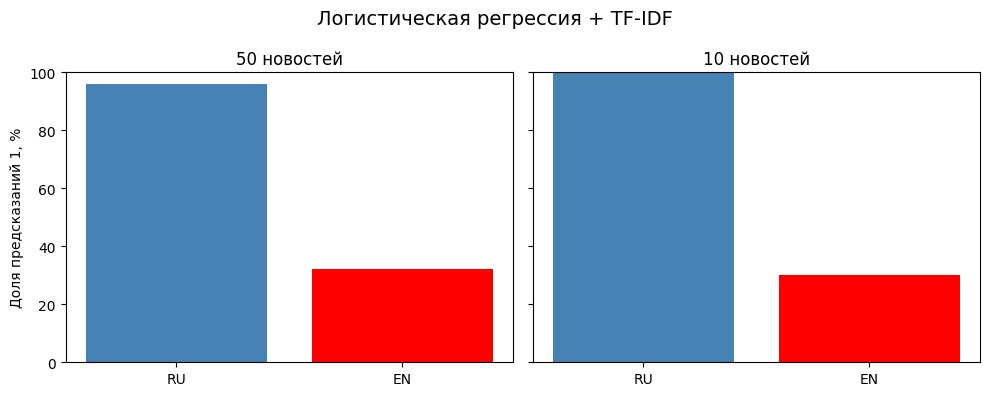

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# данные для 50 новостей
x1 = np.arange(2)
axes[0].bar(x1, [percentage_50_rus, percentage_50_eng],
            color=['steelblue', 'red'])
axes[0].set_xticks(x1)
axes[0].set_xticklabels(['RU', 'EN'])
axes[0].set_ylim(0, 100)
axes[0].set_title('50 новостей')
axes[0].set_ylabel('Доля предсказаний 1, %')

# данные для 10 новостей
x2 = np.arange(2)
axes[1].bar(x2, [percentage_10_rus, percentage_10_eng],
            color=['steelblue', 'red'])
axes[1].set_xticks(x2)
axes[1].set_xticklabels(['RU', 'EN'])
axes[1].set_ylim(0, 100)
axes[1].set_title('10 новостей')

fig.suptitle('Логистическая регрессия + TF-IDF', fontsize=14)
plt.tight_layout()
plt.show()

## Проверим Random Forest + TF-IDF

In [43]:
y_pred_english_50_tf_idf_ran_for = ran_for_eng.predict(X_test_50_eng)
y_pred_russian_50_tf_idf_ran_for = ran_for_rus.predict(X_test_50_rus)

y_pred_english_10_tf_idf_ran_for = ran_for_eng.predict(X_test_10_eng)
y_pred_russian_10_tf_idf_ran_for = ran_for_rus.predict(X_test_10_rus)

In [48]:
total_rows = len(y_pred_english_50_tf_idf_ran_for)
predictions = np.sum(y_pred_english_50_tf_idf_ran_for == 1)
percentage_50_eng = (predictions / total_rows) * 100

print(f"Общее количество строк в датасете: {total_rows}")
print(f"\nПредсказания со значением 1: {predictions} ({percentage_50_eng:.2f}%)", 2*'\n')


total_rows = len(y_pred_english_10_tf_idf_ran_for)
predictions = np.sum(y_pred_english_10_tf_idf_ran_for == 1)
percentage_10_eng = (predictions / total_rows) * 100

print(f"Общее количество строк в датасете: {total_rows}")
print(f"\nПредсказания со значением 1: {predictions} ({percentage_10_eng:.2f}%)", 2*'\n')

Общее количество строк в датасете: 50

Предсказания со значением 1: 8 (16.00%) 


Общее количество строк в датасете: 10

Предсказания со значением 1: 3 (30.00%) 




In [47]:
total_rows = len(y_pred_russian_50_tf_idf_ran_for)
predictions = np.sum(y_pred_russian_50_tf_idf_ran_for == 1)
percentage_50_rus = (predictions / total_rows) * 100

print(f"Общее количество строк в датасете: {total_rows}")
print(f"\nПредсказания со значением 1: {predictions} ({percentage_50_rus:.2f}%)", 2*'\n')


total_rows = len(y_pred_russian_10_tf_idf_ran_for)
predictions = np.sum(y_pred_russian_10_tf_idf_ran_for == 1)
percentage_10_rus = (predictions / total_rows) * 100

print(f"Общее количество строк в датасете: {total_rows}")
print(f"\nПредсказания со значением 1: {predictions} ({percentage_10_rus:.2f}%)", 2*'\n')

Общее количество строк в датасете: 50

Предсказания со значением 1: 47 (94.00%) 


Общее количество строк в датасете: 10

Предсказания со значением 1: 10 (100.00%) 




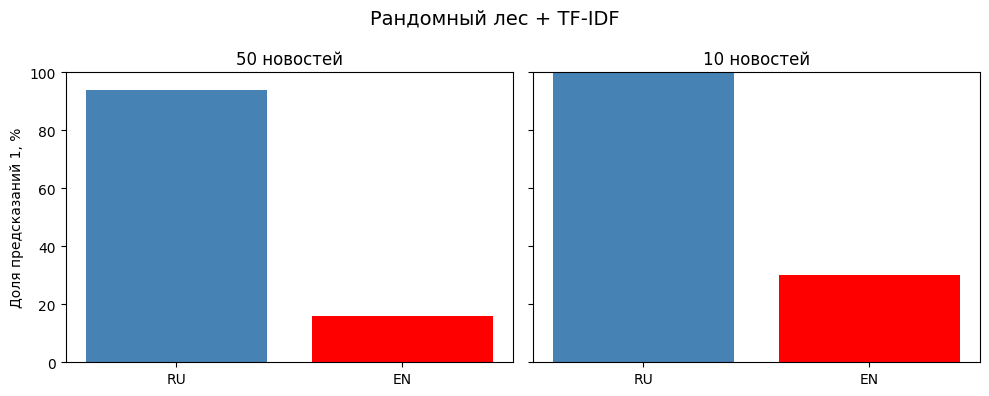

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# данные для 50 новостей
x1 = np.arange(2)
axes[0].bar(x1, [percentage_50_rus, percentage_50_eng],
            color=['steelblue', 'red'])
axes[0].set_xticks(x1)
axes[0].set_xticklabels(['RU', 'EN'])
axes[0].set_ylim(0, 100)
axes[0].set_title('50 новостей')
axes[0].set_ylabel('Доля предсказаний 1, %')

# данные для 10 новостей
x2 = np.arange(2)
axes[1].bar(x2, [percentage_10_rus, percentage_10_eng],
            color=['steelblue', 'red'])
axes[1].set_xticks(x2)
axes[1].set_xticklabels(['RU', 'EN'])
axes[1].set_ylim(0, 100)
axes[1].set_title('10 новостей')

fig.suptitle('Рандомный лес + TF-IDF', fontsize=14)
plt.tight_layout()
plt.show()

## Проверим Naive Bayes + TF-IDF

In [53]:
y_pred_english_50_tf_idf_nai_bay = nai_bay_eng.predict(X_test_50_eng)
y_pred_russian_50_tf_idf_nai_bay = nai_bay_rus.predict(X_test_50_rus)

y_pred_english_10_tf_idf_nai_bay = nai_bay_eng.predict(X_test_10_eng)
y_pred_russian_10_tf_idf_nai_bay = nai_bay_rus.predict(X_test_10_rus)

In [54]:
total_rows = len(y_pred_english_50_tf_idf_nai_bay)
predictions = np.sum(y_pred_english_50_tf_idf_nai_bay == 1)
percentage_50_eng = (predictions / total_rows) * 100

print(f"Общее количество строк в датасете: {total_rows}")
print(f"\nПредсказания со значением 1: {predictions} ({percentage_50_eng:.2f}%)", 2*'\n')


total_rows = len(y_pred_english_10_tf_idf_nai_bay)
predictions = np.sum(y_pred_english_10_tf_idf_nai_bay == 1)
percentage_10_eng = (predictions / total_rows) * 100

print(f"Общее количество строк в датасете: {total_rows}")
print(f"\nПредсказания со значением 1: {predictions} ({percentage_10_eng:.2f}%)", 2*'\n')

Общее количество строк в датасете: 50

Предсказания со значением 1: 29 (58.00%) 


Общее количество строк в датасете: 10

Предсказания со значением 1: 5 (50.00%) 




In [55]:
total_rows = len(y_pred_russian_50_tf_idf_nai_bay)
predictions = np.sum(y_pred_russian_50_tf_idf_nai_bay == 1)
percentage_50_rus = (predictions / total_rows) * 100

print(f"Общее количество строк в датасете: {total_rows}")
print(f"\nПредсказания со значением 1: {predictions} ({percentage_50_rus:.2f}%)", 2*'\n')


total_rows = len(y_pred_russian_10_tf_idf_nai_bay)
predictions = np.sum(y_pred_russian_10_tf_idf_nai_bay == 1)
percentage_10_rus = (predictions / total_rows) * 100

print(f"Общее количество строк в датасете: {total_rows}")
print(f"\nПредсказания со значением 1: {predictions} ({percentage_10_rus:.2f}%)", 2*'\n')

Общее количество строк в датасете: 50

Предсказания со значением 1: 50 (100.00%) 


Общее количество строк в датасете: 10

Предсказания со значением 1: 10 (100.00%) 




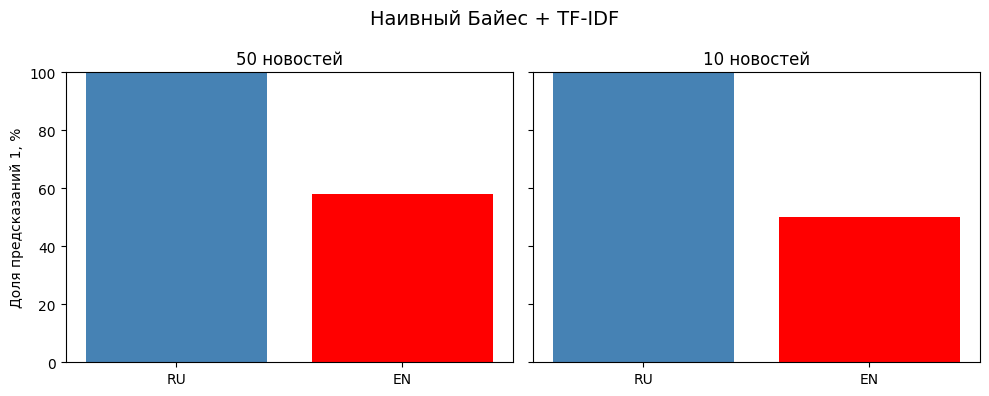

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# данные для 50 новостей
x1 = np.arange(2)
axes[0].bar(x1, [percentage_50_rus, percentage_50_eng],
            color=['steelblue', 'red'])
axes[0].set_xticks(x1)
axes[0].set_xticklabels(['RU', 'EN'])
axes[0].set_ylim(0, 100)
axes[0].set_title('50 новостей')
axes[0].set_ylabel('Доля предсказаний 1, %')

# данные для 10 новостей
x2 = np.arange(2)
axes[1].bar(x2, [percentage_10_rus, percentage_10_eng],
            color=['steelblue', 'red'])
axes[1].set_xticks(x2)
axes[1].set_xticklabels(['RU', 'EN'])
axes[1].set_ylim(0, 100)
axes[1].set_title('10 новостей')

fig.suptitle('Наивный Байес + TF-IDF', fontsize=14)
plt.tight_layout()
plt.show()